<a href="https://colab.research.google.com/github/12370043/keiichiro/blob/main/%E3%83%95%E3%83%AD%E3%83%BC%E3%82%B5%E3%82%A4%E3%83%88%E3%83%A1%E3%83%88%E3%83%AA%E3%83%BC%E6%B3%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib seaborn sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


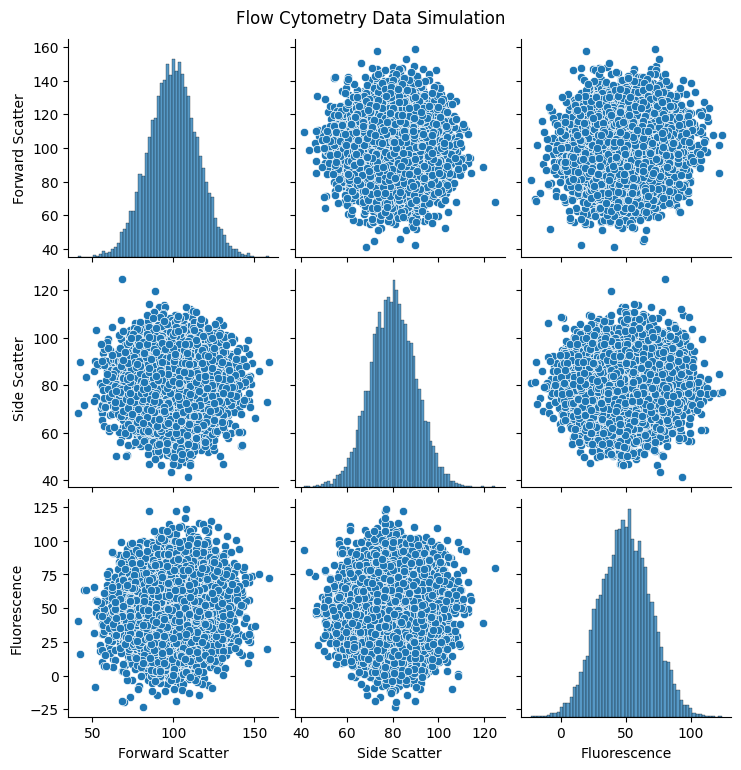

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ランダムなデータを生成
np.random.seed(42)
n_samples = 10000
data = {
    'Forward Scatter': np.random.normal(loc=100, scale=15, size=n_samples),
    'Side Scatter': np.random.normal(loc=80, scale=10, size=n_samples),
    'Fluorescence': np.random.normal(loc=50, scale=20, size=n_samples)
}

df = pd.DataFrame(data)

# データの可視化
sns.pairplot(df)
plt.suptitle('Flow Cytometry Data Simulation', y=1.02)
plt.show()

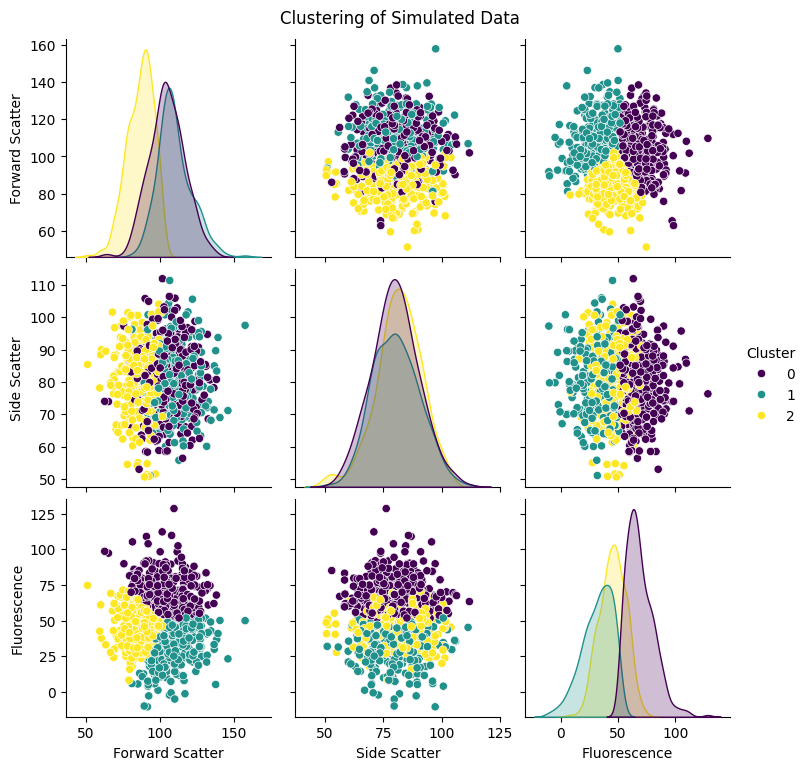

In [ ]:
from sklearn.cluster import KMeans

# クラスタリングを適用
kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(df)

# クラスタリング結果の可視化
sns.pairplot(df, hue='Cluster', palette='viridis')
plt.suptitle('Clustering of Simulated Data', y=1.02)
plt.show()

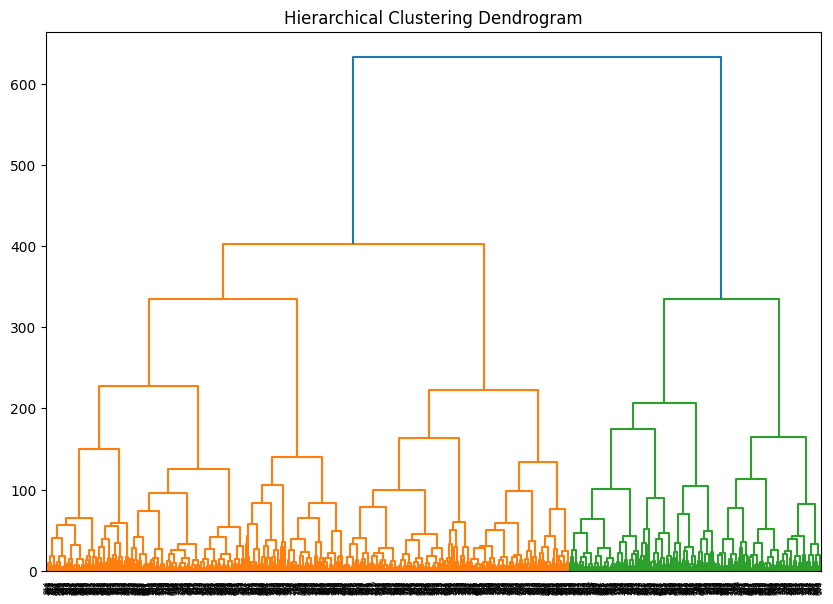

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 階層型クラスタリング
linked = linkage(df[['Forward Scatter', 'Side Scatter', 'Fluorescence']], method='ward')

# デンドログラムのプロット
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

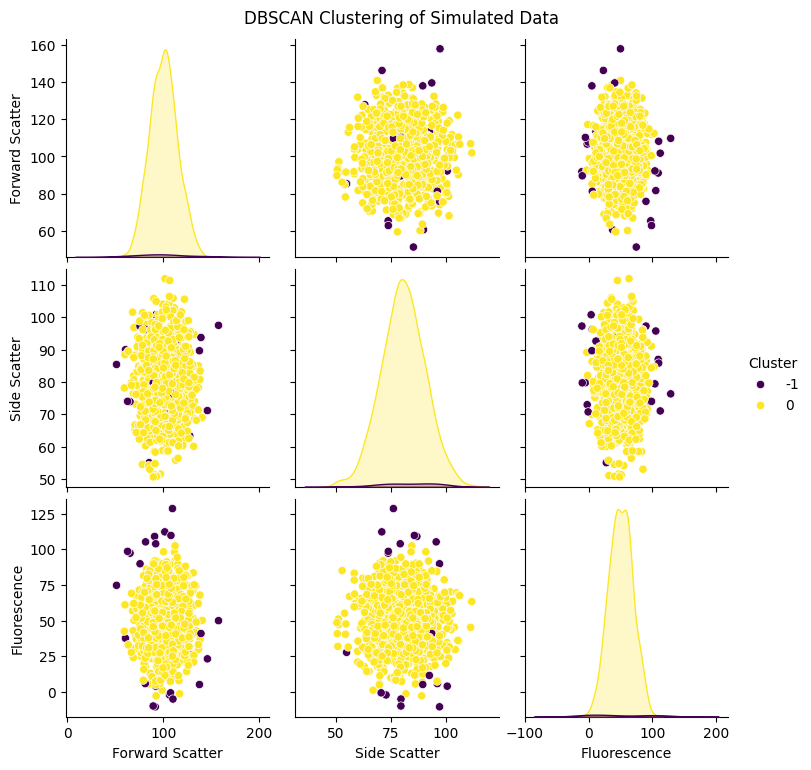

In [ ]:
from sklearn.cluster import DBSCAN

# DBSCANによるクラスタリング
dbscan = DBSCAN(eps=10, min_samples=5)
df['Cluster'] = dbscan.fit_predict(df[['Forward Scatter', 'Side Scatter', 'Fluorescence']])

# クラスタリング結果の可視化
sns.pairplot(df, hue='Cluster', palette='viridis')
plt.suptitle('DBSCAN Clustering of Simulated Data', y=1.02)
plt.show()

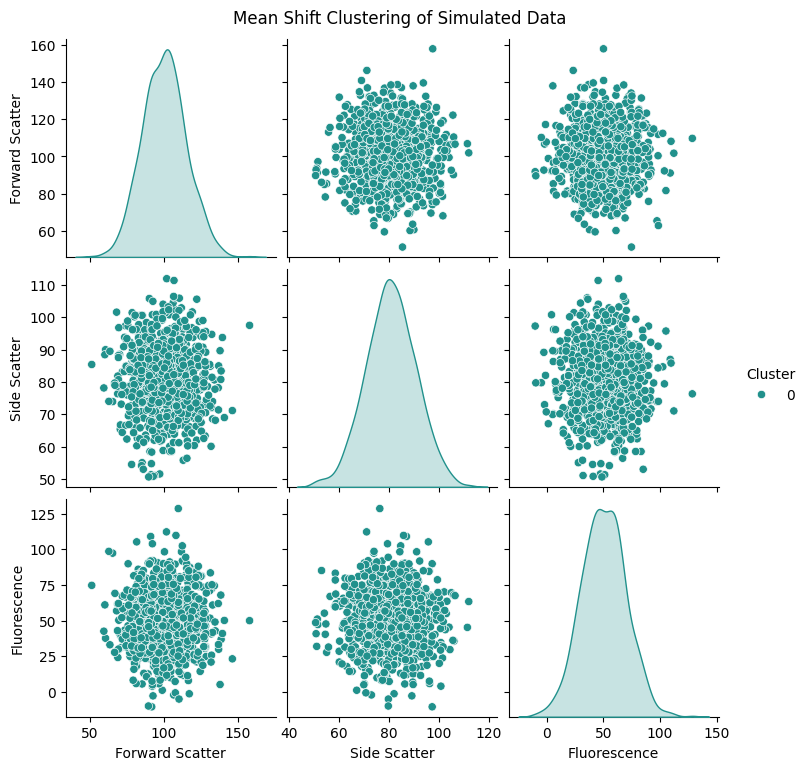

In [ ]:

from sklearn.cluster import MeanShift

# Mean Shiftによるクラスタリング
meanshift = MeanShift()
df['Cluster'] = meanshift.fit_predict(df[['Forward Scatter', 'Side Scatter', 'Fluorescence']])

# クラスタリング結果の可視化
sns.pairplot(df, hue='Cluster', palette='viridis')
plt.suptitle('Mean Shift Clustering of Simulated Data', y=1.02)
plt.show()